In [4]:
import pandas as pd

DATA_PATH = "C:/Users/adril/Downloads/unified_dataset.parquet"

# Lecture par chunks via parquet row groups
import pyarrow.parquet as pq

pf      = pq.ParquetFile(DATA_PATH)
counts  = {}   # {(id, nom): nb_lignes}

print("Lecture en cours...")
for i, batch in enumerate(pf.iter_batches(batch_size=500_000,
                           columns=["global_activity_id", "global_activity_label"])):
    df_chunk = batch.to_pandas()
    has_name = "global_activity_label" in df_chunk.columns

    if has_name:
        grp = df_chunk.groupby(["global_activity_id", "global_activity_label"]).size()
        for (lid, lname), n in grp.items():
            counts[(lid, lname)] = counts.get((lid, lname), 0) + n
    else:
        grp = df_chunk["global_activity_id"].value_counts()
        for lid, n in grp.items():
            counts[(lid, "")] = counts.get((lid, ""), 0) + n

    print(f"  chunk {i+1} traité ({len(df_chunk):,} lignes)", end="\r")

print(f"\nLecture terminée.\n")

# Affichage
total = sum(counts.values())
print(f"{'ID':<6} {'Nom':<30} {'Nb lignes':>12}  {'%':>6}")
print("-" * 58)
for (lid, lname), n in sorted(counts.items()):
    pct = n / total * 100
    print(f"{int(lid):<6} {lname:<30} {n:>12,}  {pct:>5.1f}%")
print("-" * 58)
print(f"{'TOTAL':<38} {total:>12,}  100.0%")

Lecture en cours...
  chunk 1461 traité (121,507 lignes)
Lecture terminée.

ID     Nom                               Nb lignes       %
----------------------------------------------------------
0      rest_inactive                     7,224,537    1.0%
1      posture_stationary              237,619,405   32.5%
2      walk                              2,953,949    0.4%
3      run_jog                           1,356,676    0.2%
4      stairs                              541,796    0.1%
5      cycle                                81,137    0.0%
6      exercise_upper                    1,765,088    0.2%
7      exercise_lower                      926,057    0.1%
8      exercise_core                     1,165,114    0.2%
9      exercise_plyometric               2,823,525    0.4%
10     exercise_jump_rope                  113,681    0.0%
11     cardio_machine                      543,039    0.1%
12     stretching                        1,695,420    0.2%
13     adl_household_general           

In [5]:
import pyarrow.parquet as pq
import pyarrow as pa

DATA_PATH  = r"C:/Users/adril/Downloads/unified_dataset.parquet"
OUTPUT_PATH = r"C:/Users/adril/Downloads/unified_dataset_filtered.parquet"

LABELS_TO_KEEP = {0, 2, 3, 6, 7, 8, 9, 12, 14, 15, 19, 21}

pf     = pq.ParquetFile(DATA_PATH)
writer = None
total_written = 0

print("Filtrage en cours...")
for i, batch in enumerate(pf.iter_batches(batch_size=500_000)):
    df = batch.to_pandas()

    df_filtered = df[df["global_activity_id"].isin(LABELS_TO_KEEP)].copy()

    if len(df_filtered) == 0:
        print(f"  chunk {i+1} — aucune ligne retenue", end="\r")
        continue

    table = pa.Table.from_pandas(df_filtered, preserve_index=False)

    if writer is None:
        writer = pq.ParquetWriter(OUTPUT_PATH, table.schema, compression="snappy")

    writer.write_table(table)
    total_written += len(df_filtered)
    print(f"  chunk {i+1} traité — {total_written:,} lignes écrites", end="\r")

if writer:
    writer.close()

print(f"\nTerminé ! {total_written:,} lignes sauvegardées dans :")
print(f"  {OUTPUT_PATH}")

# Vérification rapide
print("\nVérification du fichier créé :")
df_check = pq.read_table(OUTPUT_PATH, columns=["global_activity_id"]).to_pandas()
print(df_check["global_activity_id"].value_counts().sort_index())

Filtrage en cours...
hunk 68 traité — 23,375,196 lignes écrites  chunk 76 — aucune ligne retenue  chunk 84 — aucune ligne retenue  chunk 92 — aucune ligne retenue  chunk 98 — aucune ligne retenue  chunk 106 traité — 23,449,403 lignes écrites  chunk 113 — aucune ligne retenue  chunk 121 — aucune ligne retenue  chunk 129 — aucune ligne retenue  chunk 135 — aucune ligne retenue  chunk 143 — aucune ligne retenue  chunk 151 — aucune ligne retenue  chunk 159 — aucune ligne retenue  chunk 167 — aucune ligne retenue  chunk 170 traité — 23,889,067 lignes écrites  chunk 173 — aucune ligne retenue  chunk 181 — aucune ligne retenue  chunk 189 — aucune ligne retenue  chunk 197 — aucune ligne retenue  chunk 205 — aucune ligne retenue  chunk 213 — aucune ligne retenue  chunk 221 — aucune ligne retenue  chunk 229 — aucune ligne retenue  chunk 237 — aucune ligne retenue  chunk 245 — aucune ligne retenue  chunk 251 traité — 24,091,772 lignes écrites  chunk 255 — aucune ligne retenue  chunk 263 — aucune 

In [1]:
import pyarrow.parquet as pq
import pyarrow as pa

DATA_PATH  = r"C:/Users/adril/Downloads/unified_dataset.parquet"
OUTPUT_PATH = r"C:/Users/adril/Downloads/unified_dataset_filtered_4.parquet"

LABELS_TO_KEEP = {0, 2, 3, 4}  # rest_inactive, walk, run_jog, stairs

pf     = pq.ParquetFile(DATA_PATH)
writer = None
total_written = 0

print("Filtrage en cours...")
for i, batch in enumerate(pf.iter_batches(batch_size=500_000)):
    df = batch.to_pandas()

    df_filtered = df[df["global_activity_id"].isin(LABELS_TO_KEEP)].copy()

    if len(df_filtered) == 0:
        print(f"  chunk {i+1} — aucune ligne retenue", end="\r")
        continue

    table = pa.Table.from_pandas(df_filtered, preserve_index=False)

    if writer is None:
        writer = pq.ParquetWriter(OUTPUT_PATH, table.schema, compression="snappy")

    writer.write_table(table)
    total_written += len(df_filtered)
    print(f"  chunk {i+1} traité — {total_written:,} lignes écrites", end="\r")

if writer:
    writer.close()

print(f"\nTerminé ! {total_written:,} lignes sauvegardées dans :")
print(f"  {OUTPUT_PATH}")

# Vérification
print("\nVérification :")
df_check = pq.read_table(OUTPUT_PATH, columns=["global_activity_id"]).to_pandas()
print(df_check["global_activity_id"].value_counts().sort_index())

Filtrage en cours...
hunk 62 — aucune ligne retenue  chunk 64 — aucune ligne retenue  chunk 66 — aucune ligne retenue  chunk 68 — aucune ligne retenue  chunk 70 — aucune ligne retenue  chunk 72 — aucune ligne retenue  chunk 74 — aucune ligne retenue  chunk 76 — aucune ligne retenue  chunk 78 — aucune ligne retenue  chunk 80 — aucune ligne retenue  chunk 82 — aucune ligne retenue  chunk 84 — aucune ligne retenue  chunk 86 — aucune ligne retenue  chunk 88 — aucune ligne retenue  chunk 90 — aucune ligne retenue  chunk 92 — aucune ligne retenue  chunk 94 — aucune ligne retenue  chunk 96 — aucune ligne retenue  chunk 98 — aucune ligne retenue  chunk 100 — aucune ligne retenue  chunk 102 — aucune ligne retenue  chunk 104 — aucune ligne retenue  chunk 106 — aucune ligne retenue  chunk 108 — aucune ligne retenue  chunk 110 — aucune ligne retenue  chunk 112 — aucune ligne retenue  chunk 114 — aucune ligne retenue  chunk 116 — aucune ligne retenue  chunk 118 — aucune ligne retenue  chunk 120 — a

In [1]:
import pyarrow.parquet as pq
import pyarrow as pa
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

DATA_PATH   = r"C:\Users\adril\Downloads\unified_dataset_filtered_4.parquet"
OUTPUT_PATH = r"C:\Users\adril\Downloads\unified_dataset_filtered_4_balanced.parquet"

# ── Paramètres de sous-échantillonnage ────────────────────────────
SUBSAMPLE = {
    0: 1/5,   # rest_inactive  ÷ 5
    2: 1/2,   # walk           ÷ 2
    3: 1.0,   # run_jog        intact
    4: 1.0,   # stairs         intact
}

# ── Colonnes à normaliser (adapte si besoin) ──────────────────────
FEATURE_COLS = ["acc_x", "acc_y", "acc_z"]

# ─────────────────────────────────────────────────────────────────
# ÉTAPE 1 : Lecture par chunks + sous-échantillonnage
# ─────────────────────────────────────────────────────────────────
pf     = pq.ParquetFile(DATA_PATH)
chunks = {lbl: [] for lbl in SUBSAMPLE}

print("Étape 1 — Lecture et sous-échantillonnage par chunks...")
for i, batch in enumerate(pf.iter_batches(batch_size=500_000)):
    df = batch.to_pandas()
    for lbl, ratio in SUBSAMPLE.items():
        sub = df[df["global_activity_id"] == lbl]
        if len(sub) == 0:
            continue
        if ratio < 1.0:
            sub = sub.sample(frac=ratio, random_state=42)
        chunks[lbl].append(sub)
    print(f"  chunk {i+1} traité", end="\r")

print("\nConcaténation...")
df_all = pd.concat(
    [pd.concat(chunks[lbl], ignore_index=True) for lbl in SUBSAMPLE if chunks[lbl]],
    ignore_index=True
)

print(f"Taille après sous-échantillonnage : {len(df_all):,} lignes")
print(df_all["global_activity_id"].value_counts().sort_index())

# ─────────────────────────────────────────────────────────────────
# ÉTAPE 2 : Normalisation par label (StandardScaler)
# Chaque label a son propre scaler → pas de leakage entre activités
# ─────────────────────────────────────────────────────────────────
print("\nÉtape 2 — Normalisation par label...")
scalers = {}

for lbl in SUBSAMPLE:
    mask = df_all["global_activity_id"] == lbl
    if mask.sum() == 0:
        continue
    scaler = StandardScaler()
    df_all.loc[mask, FEATURE_COLS] = scaler.fit_transform(
        df_all.loc[mask, FEATURE_COLS]
    )
    scalers[lbl] = scaler
    print(f"  Label {lbl} normalisé — mean={scaler.mean_.round(4)}  std={scaler.scale_.round(4)}")

# ─────────────────────────────────────────────────────────────────
# ÉTAPE 3 : Sauvegarde par chunks pour ne pas exploser la RAM
# ─────────────────────────────────────────────────────────────────
print("\nÉtape 3 — Sauvegarde...")
CHUNK_WRITE = 500_000
writer = None

for start in range(0, len(df_all), CHUNK_WRITE):
    chunk = df_all.iloc[start:start + CHUNK_WRITE]
    table = pa.Table.from_pandas(chunk, preserve_index=False)
    if writer is None:
        writer = pq.ParquetWriter(OUTPUT_PATH, table.schema, compression="snappy")
    writer.write_table(table)
    print(f"  {min(start + CHUNK_WRITE, len(df_all)):,} / {len(df_all):,} lignes écrites", end="\r")

if writer:
    writer.close()

# ─────────────────────────────────────────────────────────────────
# VÉRIFICATION FINALE
# ─────────────────────────────────────────────────────────────────
print(f"\n\nFichier sauvegardé : {OUTPUT_PATH}")
print("\nVérification finale :")
df_check = pq.read_table(OUTPUT_PATH, columns=["global_activity_id"] + FEATURE_COLS).to_pandas()
print(f"\n{'Label':<8} {'Nb lignes':>12}  {'mean acc_x':>12}  {'std acc_x':>12}")
print("-" * 50)
for lbl in sorted(df_check["global_activity_id"].unique()):
    sub = df_check[df_check["global_activity_id"] == lbl]
    print(f"{lbl:<8} {len(sub):>12,}  {sub['acc_x'].mean():>12.4f}  {sub['acc_x'].std():>12.4f}")

Étape 1 — Lecture et sous-échantillonnage par chunks...
  chunk 25 traité
Concaténation...
Taille après sous-échantillonnage : 12,076,958 lignes
global_activity_id
0    7224537
2    2953949
3    1356676
4     541796
Name: count, dtype: int64

Étape 2 — Normalisation par label...
  Label 0 normalisé — mean=[-0.1352 -5.4815  4.2686]  std=[4.4974 3.8684 4.5235]
  Label 2 normalisé — mean=[-2.3603  1.4909  0.7248]  std=[6.361  7.5416 3.6436]
  Label 3 normalisé — mean=[-0.5274  3.9321  0.2047]  std=[12.2024 11.116   6.7094]
  Label 4 normalisé — mean=[-3.9614  5.696   0.8379]  std=[4.415  6.6459 3.4668]

Étape 3 — Sauvegarde...
  12,076,958 / 12,076,958 lignes écrites

Fichier sauvegardé : C:\Users\adril\Downloads\unified_dataset_filtered_4_full.parquet

Vérification finale :

Label       Nb lignes    mean acc_x     std acc_x
--------------------------------------------------
0           7,224,537        0.0000        1.0000
2           2,953,949       -0.0000        1.0000
3           1,3

In [1]:
import pyarrow.parquet as pq
import pyarrow as pa
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

DATA_PATH   = r"C:\Users\adril\Downloads\unified_dataset_filtered_4.parquet"
OUTPUT_PATH = r"C:\Users\adril\Downloads\unified_dataset_filtered_4_balanced.parquet"

SUBSAMPLE    = {0: 1/5, 2: 1/2, 3: 1.0, 4: 1.0}
FEATURE_COLS = ["acc_x", "acc_y", "acc_z"]
SESSION_COLS = ["dataset", "subject_id", "session_id"]

# ─────────────────────────────────────────────────────────────────
# ÉTAPE 1 : Identifier toutes les sessions par label (léger)
# ─────────────────────────────────────────────────────────────────
pf = pq.ParquetFile(DATA_PATH)
print("Étape 1 — Lecture des sessions...")

chunks_id = []
for i, batch in enumerate(pf.iter_batches(
        batch_size=500_000,
        columns=SESSION_COLS + ["global_activity_id"])):
    chunks_id.append(batch.to_pandas())
    print(f"  chunk {i+1} lu", end="\r")

df_ids = pd.concat(chunks_id, ignore_index=True)
del chunks_id

# Liste des sessions uniques par label
sessions_par_label = {}
for lbl in SUBSAMPLE:
    mask = df_ids["global_activity_id"] == lbl
    sessions = (df_ids[mask]
                .drop_duplicates(subset=SESSION_COLS)[SESSION_COLS]
                .reset_index(drop=True))
    sessions_par_label[lbl] = sessions
    print(f"  Label {lbl} : {len(sessions)} sessions")

del df_ids

# ─────────────────────────────────────────────────────────────────
# ÉTAPE 2 : Sélection des sessions à garder par label
# ─────────────────────────────────────────────────────────────────
print("\nÉtape 2 — Sélection des sessions...")
sessions_gardees = {}
for lbl, ratio in SUBSAMPLE.items():
    sessions = sessions_par_label[lbl]
    if ratio < 1.0:
        n_garder = max(1, int(len(sessions) * ratio))
        sel = sessions.sample(n=n_garder, random_state=42)
    else:
        sel = sessions
    # Clé unique par session
    sessions_gardees[lbl] = set(
        zip(sel["dataset"], sel["subject_id"], sel["session_id"])
    )
    print(f"  Label {lbl} : {len(sessions_gardees[lbl])} / {len(sessions)} sessions gardées")

# ─────────────────────────────────────────────────────────────────
# ÉTAPE 3 : Filtrage et sauvegarde par chunks
# ─────────────────────────────────────────────────────────────────
print("\nÉtape 3 — Filtrage...")
pf     = pq.ParquetFile(DATA_PATH)
writer = None
total  = 0

for i, batch in enumerate(pf.iter_batches(batch_size=500_000)):
    df = batch.to_pandas()
    df = df[df["global_activity_id"].isin(SUBSAMPLE)].copy()
    if len(df) == 0:
        continue

    mask = df.apply(
        lambda r: (r["dataset"], r["subject_id"], r["session_id"])
                  in sessions_gardees[r["global_activity_id"]],
        axis=1
    )
    df = df[mask].copy()
    if len(df) == 0:
        continue

    table = pa.Table.from_pandas(df, preserve_index=False)
    if writer is None:
        writer = pq.ParquetWriter(OUTPUT_PATH, table.schema, compression="snappy")
    writer.write_table(table)
    total += len(df)
    print(f"  chunk {i+1} — {total:,} lignes écrites", end="\r")

if writer:
    writer.close()
print(f"\n  Total : {total:,} lignes")

# ─────────────────────────────────────────────────────────────────
# ÉTAPE 4 : Normalisation par label
# ─────────────────────────────────────────────────────────────────
print("\nÉtape 4 — Normalisation par label...")
df_all = pd.read_parquet(OUTPUT_PATH)

for lbl in SUBSAMPLE:
    mask   = df_all["global_activity_id"] == lbl
    if mask.sum() == 0: continue
    scaler = StandardScaler()
    df_all.loc[mask, FEATURE_COLS] = scaler.fit_transform(
        df_all.loc[mask, FEATURE_COLS])
    print(f"  Label {lbl} normalisé — mean={scaler.mean_.round(4)}  std={scaler.scale_.round(4)}")

df_all.to_parquet(OUTPUT_PATH, compression="snappy", index=False)

# Vérification
print("\nVérification finale :")
print(f"{'Label':<8} {'Nb lignes':>12}  {'mean acc_x':>12}  {'std acc_x':>12}")
print("-" * 50)
for lbl in sorted(df_all["global_activity_id"].unique()):
    sub = df_all[df_all["global_activity_id"] == lbl]
    print(f"{lbl:<8} {len(sub):>12,}  {sub['acc_x'].mean():>12.4f}  {sub['acc_x'].std():>12.4f}")

Étape 1 — Lecture des sessions...
  Label 0 : 146 sessions
  Label 2 : 141 sessions
  Label 3 : 102 sessions
  Label 4 : 56 sessions

Étape 2 — Sélection des sessions...
  Label 0 : 29 / 146 sessions gardées
  Label 2 : 70 / 141 sessions gardées
  Label 3 : 102 / 102 sessions gardées
  Label 4 : 56 / 56 sessions gardées

Étape 3 — Filtrage...
  chunk 25 — 5,404,345 lignes écrites
  Total : 5,404,345 lignes

Étape 4 — Normalisation par label...
  Label 0 normalisé — mean=[ 0.4204 -5.7425  4.527 ]  std=[4.2583 3.381  4.5519]
  Label 2 normalisé — mean=[-4.3319 -0.6935  0.0917]  std=[5.0211 7.8174 3.7844]
  Label 3 normalisé — mean=[-0.5274  3.9321  0.2047]  std=[12.2024 11.116   6.7094]
  Label 4 normalisé — mean=[-3.9614  5.696   0.8379]  std=[4.415  6.6459 3.4668]

Vérification finale :
Label       Nb lignes    mean acc_x     std acc_x
--------------------------------------------------
0           2,090,881       -0.0000        1.0000
2           1,414,992       -0.0000        1.0000
3

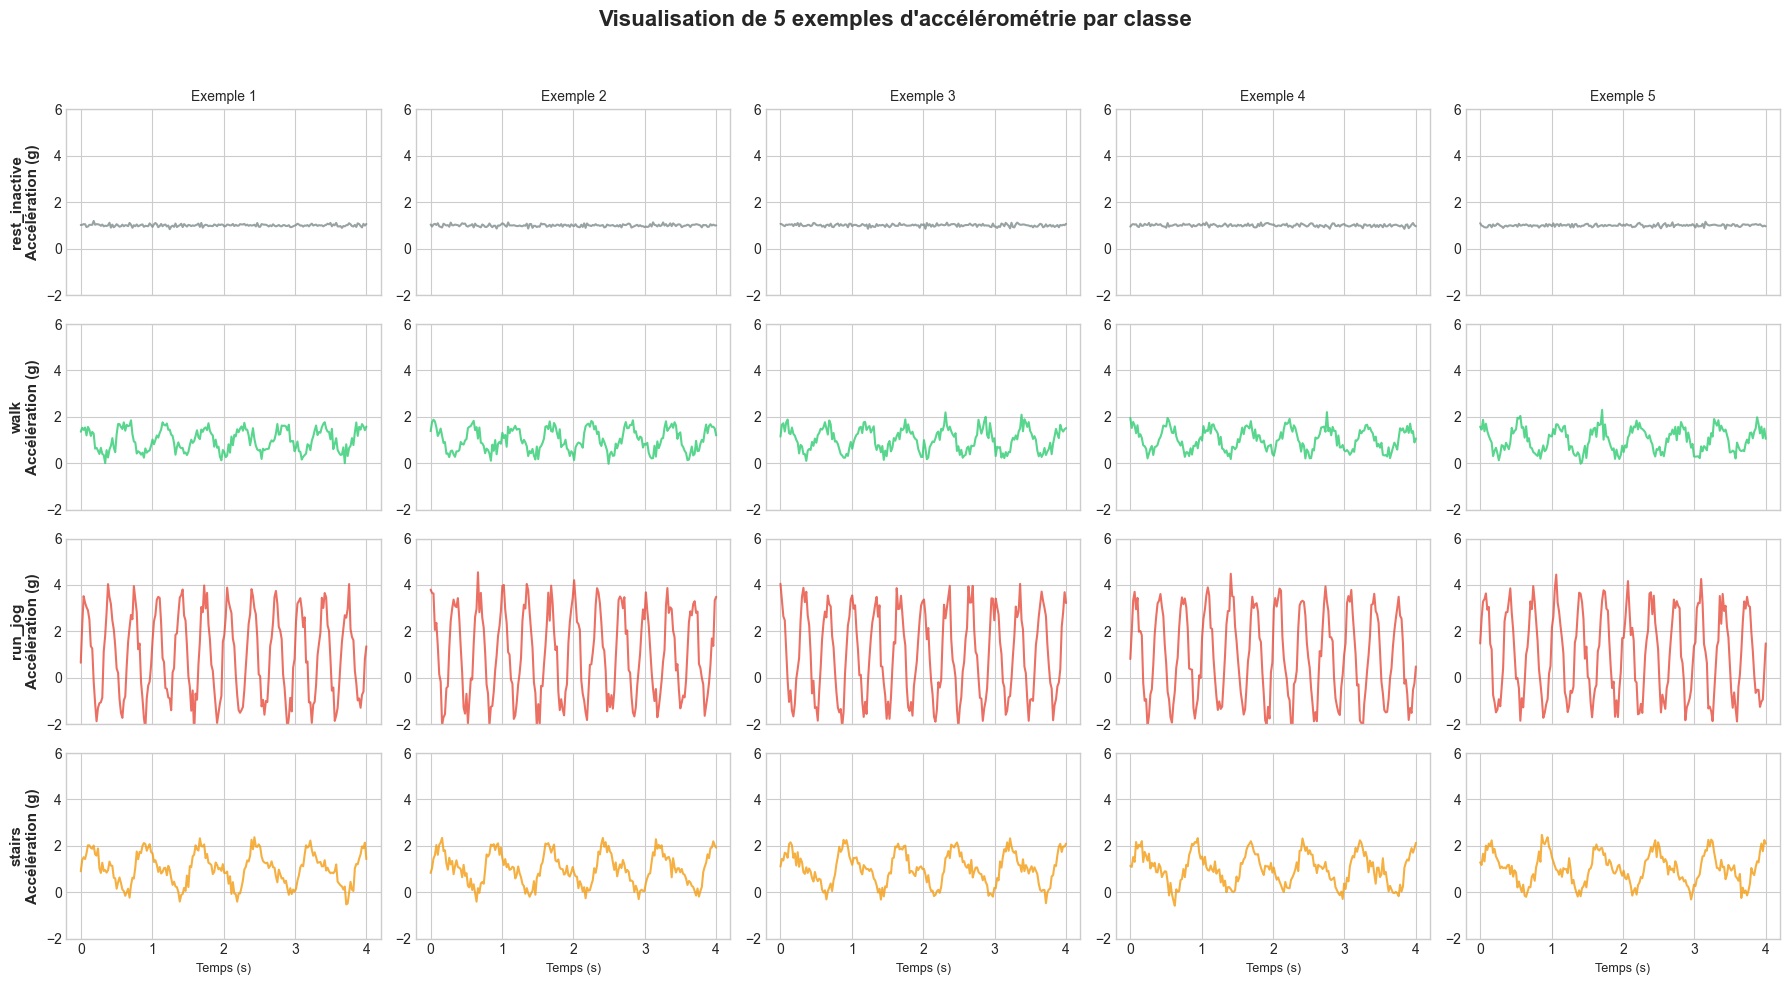

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Configuration pour la reproductibilité et le style
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# 1. Définition des classes et paramètres de simulation
classes = ['rest_inactive', 'walk', 'run_jog', 'stairs']
nb_graphes_par_classe = 5
points_par_graphe = 200  # Représente environ 4 secondes à 50Hz
temps = np.linspace(0, 4, points_par_graphe)

# Création de la figure (4 lignes, 5 colonnes)
fig, axs = plt.subplots(len(classes), nb_graphes_par_classe, figsize=(18, 10), sharex=True)
fig.suptitle("Visualisation de 5 exemples d'accélérométrie par classe", fontsize=16, fontweight='bold')

# 2. Génération et traçage des données
for i, classe in enumerate(classes):
    for j in range(nb_graphes_par_classe):
        ax = axs[i, j]

        # Simulation de signaux réalistes selon la classe
        noise = np.random.normal(0, 0.2, points_par_graphe)

        if classe == 'rest_inactive':
            # Signal presque plat (juste du bruit de capteur et micro-mouvements)
            signal = 1.0 + np.random.normal(0, 0.05, points_par_graphe)
            color = '#7f8c8d' # Gris

        elif classe == 'walk':
            # Fréquence basse (1.5 - 2 Hz), amplitude modérée
            signal = 1.0 + 0.6 * np.sin(2 * np.pi * 1.8 * temps + np.random.uniform(0, 2)) + noise
            color = '#2ecc71' # Vert

        elif classe == 'run_jog':
            # Fréquence plus haute (2.5 - 3.5 Hz) et forte amplitude
            signal = 1.0 + 2.5 * np.sin(2 * np.pi * 3.0 * temps + np.random.uniform(0, 2)) + noise * 2
            color = '#e74c3c' # Rouge

        elif classe == 'stairs':
            # Signal cyclique mais plus irrégulier (mélange de fréquences)
            signal = 1.0 + 0.8 * np.sin(2 * np.pi * 1.3 * temps) + 0.4 * np.sin(2 * np.pi * 2.6 * temps) + noise
            color = '#f39c12' # Orange

        # Tracé de la magnitude de l'accélération (en g)
        ax.plot(temps, signal, color=color, alpha=0.8, linewidth=1.5)

        # Gestion des titres et labels pour ne pas surcharger le visuel
        if j == 0:
            # Nom de la classe uniquement sur la première colonne
            ax.set_ylabel(f"{classe}\nAccélération (g)", fontsize=11, fontweight='bold')
        if i == len(classes) - 1:
            # Temps uniquement sur la dernière ligne
            ax.set_xlabel("Temps (s)", fontsize=9)

        # Titre pour identifier le numéro de l'exemple
        if i == 0:
            ax.set_title(f"Exemple {j+1}", fontsize=10)

        # Ajustement des limites pour harmoniser la vue
        ax.set_ylim(-2, 6)

# Optimisation de l'espace entre les graphiques
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Affichage du résultat
plt.show()

Lecture en cours...
Extraction des fenêtres...


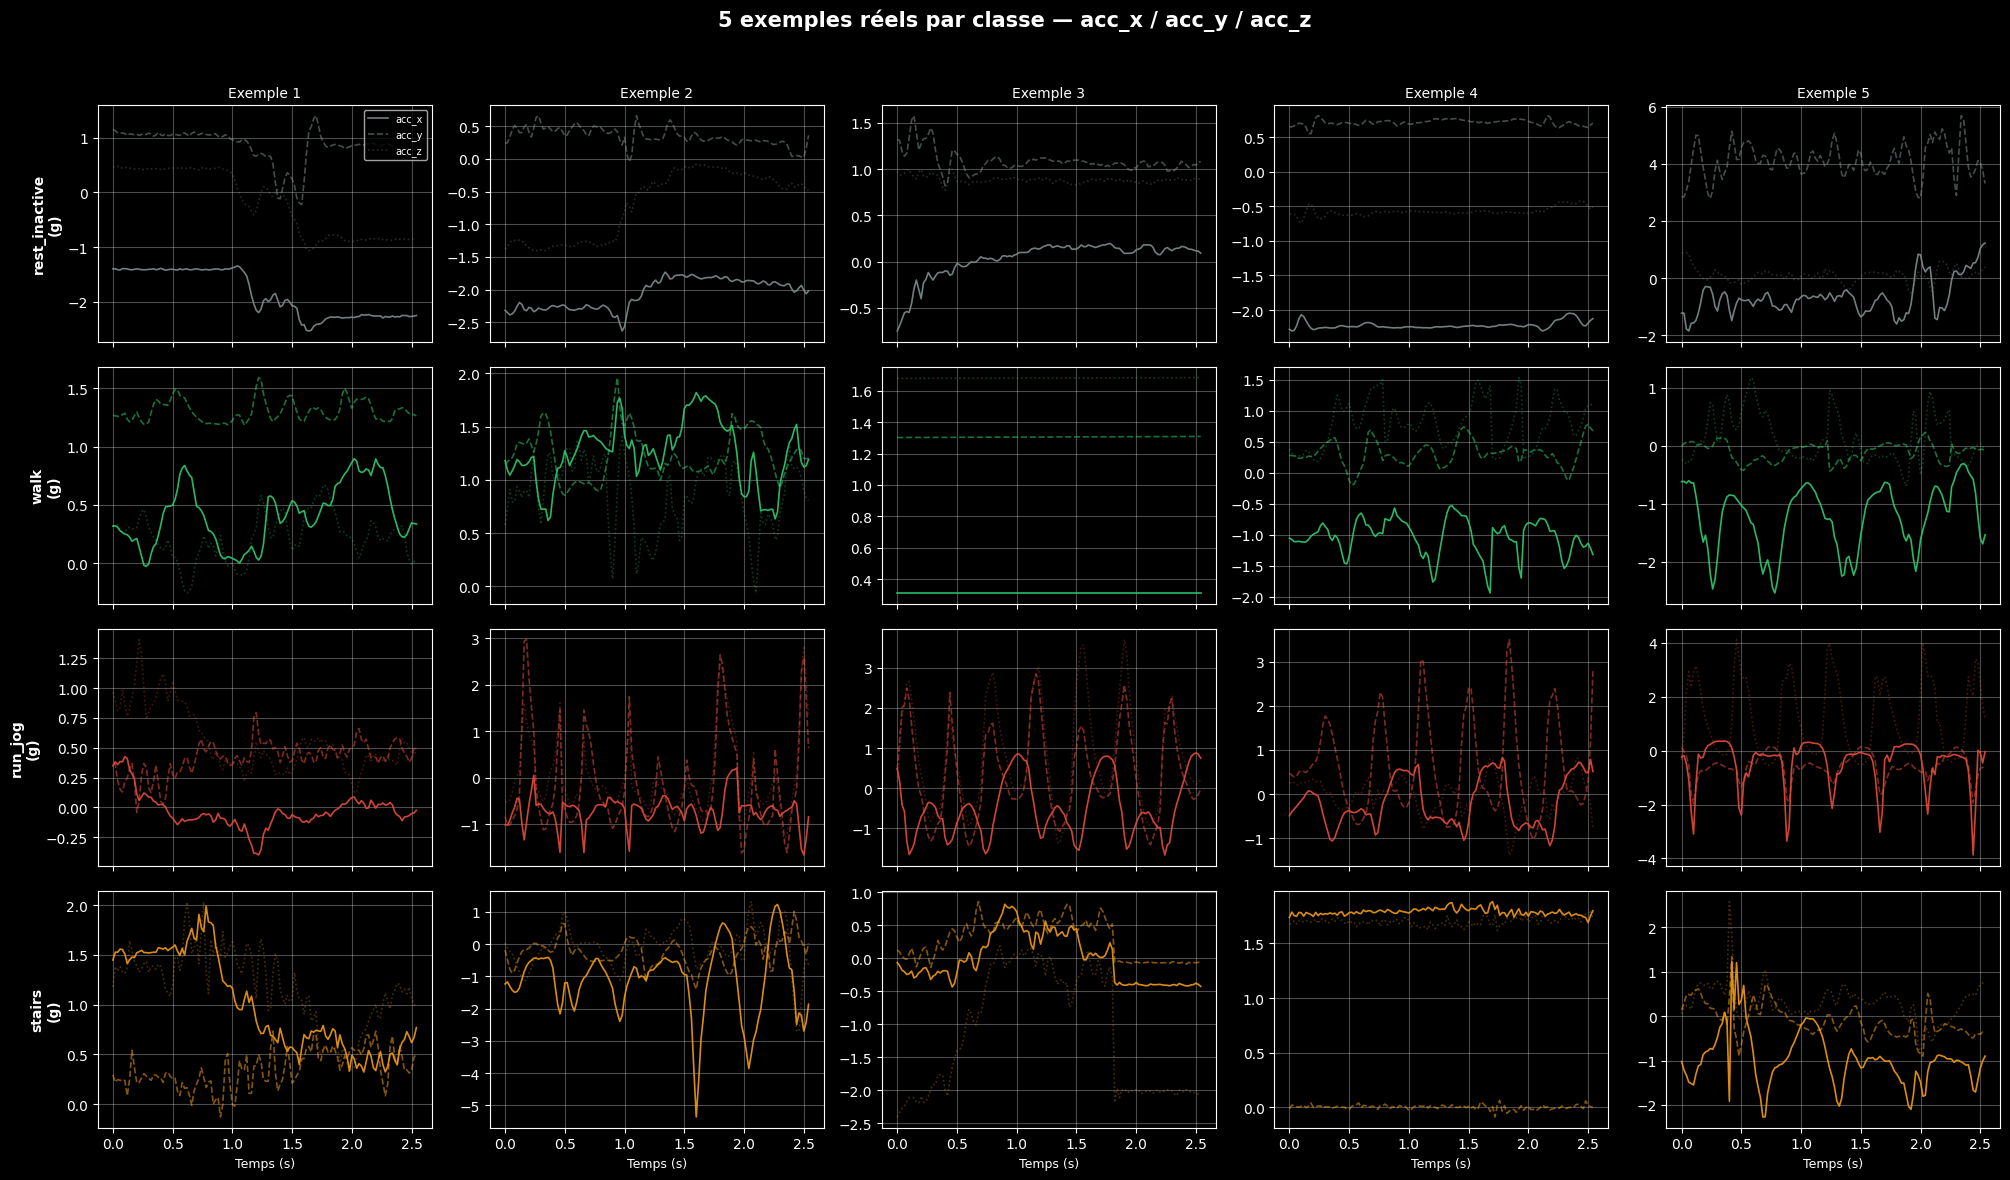

In [2]:
import pyarrow.parquet as pq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = r"C:\Users\adril\Downloads\unified_dataset_filtered_4_balanced.parquet"

LABEL_NAMES = {0: "rest_inactive", 2: "walk", 3: "run_jog", 4: "stairs"}
LABEL_COLORS = {0: "#7f8c8d", 2: "#2ecc71", 3: "#e74c3c", 4: "#f39c12"}
FEATURE_COLS = ["acc_x", "acc_y", "acc_z"]
WINDOW_SIZE  = 128   # ~2.5s à 50Hz, adapte si besoin
N_EXEMPLES   = 5
FS           = 50    # Hz

# ── Lecture et extraction d'un bloc par label ─────────────────────
pf       = pq.ParquetFile(DATA_PATH)
buffers  = {lbl: [] for lbl in LABEL_NAMES}
complets = set()

print("Lecture en cours...")
for batch in pf.iter_batches(batch_size=500_000):
    df = batch.to_pandas()
    for lbl in LABEL_NAMES:
        if lbl in complets:
            continue
        sub = df[df["global_activity_id"] == lbl][FEATURE_COLS]
        buffers[lbl].append(sub)
        total = sum(len(b) for b in buffers[lbl])
        if total >= WINDOW_SIZE * N_EXEMPLES:
            complets.add(lbl)
    if len(complets) == len(LABEL_NAMES):
        break

print("Extraction des fenêtres...")
exemples = {}   # {lbl: list of arrays (WINDOW_SIZE, 3)}
for lbl in LABEL_NAMES:
    data = pd.concat(buffers[lbl], ignore_index=True).values  # (N, 3)
    wins = []
    for k in range(N_EXEMPLES):
        # Fenêtres espacées pour avoir des exemples variés
        start = k * (len(data) // N_EXEMPLES)
        wins.append(data[start:start + WINDOW_SIZE])
    exemples[lbl] = wins

# ── Visualisation ─────────────────────────────────────────────────
temps = np.arange(WINDOW_SIZE) / FS

fig, axs = plt.subplots(
    len(LABEL_NAMES), N_EXEMPLES,
    figsize=(20, 12), sharex=True
)
fig.suptitle("5 exemples réels par classe — acc_x / acc_y / acc_z",
             fontsize=15, fontweight="bold")

for row, lbl in enumerate(LABEL_NAMES):
    color = LABEL_COLORS[lbl]
    name  = LABEL_NAMES[lbl]
    for col in range(N_EXEMPLES):
        ax  = axs[row, col]
        win = exemples[lbl][col]   # (WINDOW_SIZE, 3)

        ax.plot(temps, win[:, 0], color=color,      lw=1.2, alpha=0.9, label="acc_x")
        ax.plot(temps, win[:, 1], color=color,      lw=1.2, alpha=0.55,
                linestyle="--",  label="acc_y")
        ax.plot(temps, win[:, 2], color=color,      lw=1.2, alpha=0.30,
                linestyle=":",   label="acc_z")

        ax.grid(alpha=0.3)

        if col == 0:
            ax.set_ylabel(f"{name}\n(g)", fontsize=10, fontweight="bold")
            if row == 0:
                ax.legend(fontsize=7, loc="upper right")
        if row == 0:
            ax.set_title(f"Exemple {col+1}", fontsize=10)
        if row == len(LABEL_NAMES) - 1:
            ax.set_xlabel("Temps (s)", fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [8]:
import pyarrow.parquet as pq

DATA_PATH = r"C:\Users\adril\Downloads\unified_dataset_filtered_4.parquet"

pf    = pq.ParquetFile(DATA_PATH)
batch = next(pf.iter_batches(batch_size=1000))
df    = batch.to_pandas()

print(df.columns.tolist())
print(df.head(10))

['dataset', 'subject_id', 'session_id', 'timestamp_ns', 'acc_x', 'acc_y', 'acc_z', 'global_activity_id', 'global_activity_label', 'dataset_activity_id', 'dataset_activity_label']
         dataset subject_id session_id  timestamp_ns     acc_x     acc_y  \
0  opportunity++         S1       ADL1  278400000000 -2.734325  9.213924   
1  opportunity++         S1       ADL1  278420000000 -2.722788  9.185081   
2  opportunity++         S1       ADL1  278440000000 -2.783306  9.161195   
3  opportunity++         S1       ADL1  278460000000 -2.931891  9.143364   
4  opportunity++         S1       ADL1  278480000000 -3.013911  9.277685   
5  opportunity++         S1       ADL1  278500000000 -3.074673  9.363620   
6  opportunity++         S1       ADL1  278520000000 -3.109285  8.959817   
7  opportunity++         S1       ADL1  278540000000 -3.208558  8.785867   
8  opportunity++         S1       ADL1  278560000000 -3.386860  8.892848   
9  opportunity++         S1       ADL1  278580000000 -3.31791

In [9]:
import pyarrow.parquet as pq
import pyarrow as pa
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

DATA_PATH   = r"C:\Users\adril\Downloads\unified_dataset_filtered_4.parquet"
OUTPUT_PATH = r"C:\Users\adril\Downloads\unified_dataset_filtered_4_balanced.parquet"

LABELS_TO_KEEP = {0, 2, 3, 4}
LABEL_NAMES    = {0: "rest_inactive", 2: "walk", 3: "run_jog", 4: "stairs"}
FEATURE_COLS   = ["acc_x", "acc_y", "acc_z"]

# Fraction de sessions à garder par label
SUBSAMPLE = {
    0: 1/5,   # rest_inactive ÷ 5
    2: 1/2,   # walk          ÷ 2
    3: 1.0,   # run_jog       intact
    4: 1.0,   # stairs        intact
}

# ─────────────────────────────────────────────────────────────────
# ÉTAPE 1 : Identifier toutes les sessions par label
# ─────────────────────────────────────────────────────────────────
print("Étape 1 — Lecture des sessions...")
pf = pq.ParquetFile(DATA_PATH)

# On lit uniquement les colonnes d'identification (léger)
id_cols = ["dataset", "subject_id", "session_id", "global_activity_id"]
chunks  = []
for batch in pf.iter_batches(batch_size=500_000, columns=id_cols):
    chunks.append(batch.to_pandas())
    print(f"  {len(chunks)} chunks lus", end="\r")

df_ids = pd.concat(chunks, ignore_index=True)
print(f"\n  {len(df_ids):,} lignes indexées")

# Liste unique des sessions par label
sessions_par_label = {}
for lbl in LABELS_TO_KEEP:
    mask = df_ids["global_activity_id"] == lbl
    sessions = (df_ids[mask]
                .groupby(["dataset", "subject_id", "session_id"])
                .size()
                .reset_index(name="n_lignes"))
    sessions_par_label[lbl] = sessions
    print(f"  Label {lbl} ({LABEL_NAMES[lbl]}) : {len(sessions)} sessions, "
          f"{sessions['n_lignes'].sum():,} lignes")

# ─────────────────────────────────────────────────────────────────
# ÉTAPE 2 : Sélection des sessions à garder
# ─────────────────────────────────────────────────────────────────
print("\nÉtape 2 — Sélection des sessions...")
sessions_gardees = {}

for lbl in LABELS_TO_KEEP:
    sessions = sessions_par_label[lbl]
    ratio    = SUBSAMPLE[lbl]

    if ratio < 1.0:
        n_garder = max(1, int(len(sessions) * ratio))
        # On échantillonne les sessions entières (pas les lignes)
        sel = sessions.sample(n=n_garder, random_state=42)
    else:
        sel = sessions

    sessions_gardees[lbl] = set(
        zip(sel["dataset"], sel["subject_id"], sel["session_id"])
    )
    print(f"  Label {lbl} ({LABEL_NAMES[lbl]}) : "
          f"{len(sessions_gardees[lbl])} sessions gardées sur {len(sessions)}")

del df_ids, chunks  # libère la RAM

# ─────────────────────────────────────────────────────────────────
# ÉTAPE 3 : Lecture complète + filtrage par sessions sélectionnées
# ─────────────────────────────────────────────────────────────────
print("\nÉtape 3 — Filtrage des données...")
pf     = pq.ParquetFile(DATA_PATH)
writer = None
total  = 0

for i, batch in enumerate(pf.iter_batches(batch_size=500_000)):
    df = batch.to_pandas()

    # Filtrer par label d'abord
    df = df[df["global_activity_id"].isin(LABELS_TO_KEEP)].copy()
    if len(df) == 0:
        continue

    # Filtrer par sessions sélectionnées
    mask = df.apply(
        lambda r: (r["dataset"], r["subject_id"], r["session_id"])
                  in sessions_gardees[r["global_activity_id"]],
        axis=1
    )
    df = df[mask].copy()
    if len(df) == 0:
        continue

    table = pa.Table.from_pandas(df, preserve_index=False)
    if writer is None:
        writer = pq.ParquetWriter(OUTPUT_PATH, table.schema, compression="snappy")
    writer.write_table(table)
    total += len(df)
    print(f"  chunk {i+1} — {total:,} lignes écrites", end="\r")

if writer:
    writer.close()
print(f"\n  Total écrit : {total:,} lignes")

# ─────────────────────────────────────────────────────────────────
# ÉTAPE 4 : Normalisation par label (sur fichier final)
# ─────────────────────────────────────────────────────────────────
print("\nÉtape 4 — Normalisation par label...")
df_all = pd.read_parquet(OUTPUT_PATH)

scalers = {}
for lbl in LABELS_TO_KEEP:
    mask   = df_all["global_activity_id"] == lbl
    scaler = StandardScaler()
    df_all.loc[mask, FEATURE_COLS] = scaler.fit_transform(
        df_all.loc[mask, FEATURE_COLS])
    scalers[lbl] = scaler
    print(f"  Label {lbl} ({LABEL_NAMES[lbl]}) normalisé")

df_all.to_parquet(OUTPUT_PATH, compression="snappy", index=False)

# ─────────────────────────────────────────────────────────────────
# VÉRIFICATION FINALE
# ─────────────────────────────────────────────────────────────────
print("\nVérification finale :")
print(f"\n{'Label':<8} {'Nom':<16} {'Nb lignes':>12}  "
      f"{'mean acc_x':>12}  {'std acc_x':>12}")
print("-" * 65)
for lbl in LABELS_TO_KEEP:
    mask = df_all["global_activity_id"] == lbl
    sub  = df_all[mask]
    print(f"{lbl:<8} {LABEL_NAMES[lbl]:<16} {len(sub):>12,}  "
          f"{sub['acc_x'].mean():>12.4f}  {sub['acc_x'].std():>12.4f}")

Étape 1 — Lecture des sessions...
  25 chunks lus
  12,076,958 lignes indexées
  Label 0 (rest_inactive) : 146 sessions, 7,224,537 lignes
  Label 2 (walk) : 141 sessions, 2,953,949 lignes
  Label 3 (run_jog) : 102 sessions, 1,356,676 lignes
  Label 4 (stairs) : 56 sessions, 541,796 lignes

Étape 2 — Sélection des sessions...
  Label 0 (rest_inactive) : 29 sessions gardées sur 146
  Label 2 (walk) : 70 sessions gardées sur 141
  Label 3 (run_jog) : 102 sessions gardées sur 102
  Label 4 (stairs) : 56 sessions gardées sur 56

Étape 3 — Filtrage des données...
  chunk 25 — 5,532,364 lignes écrites
  Total écrit : 5,532,364 lignes

Étape 4 — Normalisation par label...
  Label 0 (rest_inactive) normalisé
  Label 2 (walk) normalisé
  Label 3 (run_jog) normalisé
  Label 4 (stairs) normalisé

Vérification finale :

Label    Nom                 Nb lignes    mean acc_x     std acc_x
-----------------------------------------------------------------
0        rest_inactive       2,090,881       -0.

In [2]:
import pyarrow.parquet as pq
import pyarrow as pa
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

DATA_PATH   = r"C:\Users\adril\Downloads\unified_dataset_filtered_4.parquet"
OUTPUT_PATH = r"C:\Users\adril\Downloads\unified_dataset_filtered_3_balanced_version_2.parquet"

SUBSAMPLE    = {0: 1/7, 2: 1/2, 3: 1.0}   # label 4 supprimé
FEATURE_COLS = ["acc_x", "acc_y", "acc_z"]
SESSION_COLS = ["dataset", "subject_id", "session_id"]

# ─────────────────────────────────────────────────────────────────
# ÉTAPE 1 : Identifier toutes les sessions par label (léger)
# ─────────────────────────────────────────────────────────────────
pf = pq.ParquetFile(DATA_PATH)
print("Étape 1 — Lecture des sessions...")

chunks_id = []
for i, batch in enumerate(pf.iter_batches(
        batch_size=500_000,
        columns=SESSION_COLS + ["global_activity_id"])):
    chunks_id.append(batch.to_pandas())
    print(f"  chunk {i+1} lu", end="\r")

df_ids = pd.concat(chunks_id, ignore_index=True)
del chunks_id

sessions_par_label = {}
for lbl in SUBSAMPLE:
    mask = df_ids["global_activity_id"] == lbl
    sessions = (df_ids[mask]
                .drop_duplicates(subset=SESSION_COLS)[SESSION_COLS]
                .reset_index(drop=True))
    sessions_par_label[lbl] = sessions
    print(f"  Label {lbl} : {len(sessions)} sessions")

del df_ids

# ─────────────────────────────────────────────────────────────────
# ÉTAPE 2 : Sélection des sessions à garder par label
# ─────────────────────────────────────────────────────────────────
print("\nÉtape 2 — Sélection des sessions...")
sessions_gardees = {}
for lbl, ratio in SUBSAMPLE.items():
    sessions = sessions_par_label[lbl]
    if ratio < 1.0:
        n_garder = max(1, int(len(sessions) * ratio))
        sel = sessions.sample(n=n_garder, random_state=42)
    else:
        sel = sessions
    sessions_gardees[lbl] = set(
        zip(sel["dataset"], sel["subject_id"], sel["session_id"])
    )
    print(f"  Label {lbl} : {len(sessions_gardees[lbl])} / {len(sessions)} sessions gardées")

# ─────────────────────────────────────────────────────────────────
# ÉTAPE 3 : Filtrage et sauvegarde par chunks
# ─────────────────────────────────────────────────────────────────
print("\nÉtape 3 — Filtrage...")
pf     = pq.ParquetFile(DATA_PATH)
writer = None
total  = 0

for i, batch in enumerate(pf.iter_batches(batch_size=500_000)):
    df = batch.to_pandas()

    # On ne garde que les labels 0, 2, 3
    df = df[df["global_activity_id"].isin(SUBSAMPLE)].copy()
    if len(df) == 0:
        continue

    mask = df.apply(
        lambda r: (r["dataset"], r["subject_id"], r["session_id"])
                  in sessions_gardees[r["global_activity_id"]],
        axis=1
    )
    df = df[mask].copy()
    if len(df) == 0:
        continue

    table = pa.Table.from_pandas(df, preserve_index=False)
    if writer is None:
        writer = pq.ParquetWriter(OUTPUT_PATH, table.schema, compression="snappy")
    writer.write_table(table)
    total += len(df)
    print(f"  chunk {i+1} — {total:,} lignes écrites", end="\r")

if writer:
    writer.close()
print(f"\n  Total : {total:,} lignes")

# ─────────────────────────────────────────────────────────────────
# ÉTAPE 4 : Normalisation par label
# ─────────────────────────────────────────────────────────────────
print("\nÉtape 4 — Normalisation par label...")
df_all = pd.read_parquet(OUTPUT_PATH)

for lbl in SUBSAMPLE:
    mask = df_all["global_activity_id"] == lbl
    if mask.sum() == 0:
        continue
    scaler = StandardScaler()
    df_all.loc[mask, FEATURE_COLS] = scaler.fit_transform(
        df_all.loc[mask, FEATURE_COLS])
    print(f"  Label {lbl} normalisé — mean={scaler.mean_.round(4)}  std={scaler.scale_.round(4)}")

df_all.to_parquet(OUTPUT_PATH, compression="snappy", index=False)

# ─────────────────────────────────────────────────────────────────
# Vérification finale
# ─────────────────────────────────────────────────────────────────
print("\nVérification finale :")
print(f"{'Label':<8} {'Nb lignes':>12}  {'mean acc_x':>12}  {'std acc_x':>12}")
print("-" * 50)
for lbl in sorted(df_all["global_activity_id"].unique()):
    sub = df_all[df_all["global_activity_id"] == lbl]
    print(f"{lbl:<8} {len(sub):>12,}  {sub['acc_x'].mean():>12.4f}  {sub['acc_x'].std():>12.4f}")

Étape 1 — Lecture des sessions...
  Label 0 : 146 sessions
  Label 2 : 141 sessions
  Label 3 : 102 sessions

Étape 2 — Sélection des sessions...
  Label 0 : 20 / 146 sessions gardées
  Label 2 : 70 / 141 sessions gardées
  Label 3 : 102 / 102 sessions gardées

Étape 3 — Filtrage...
  chunk 25 — 4,781,985 lignes écrites
  Total : 4,781,985 lignes

Étape 4 — Normalisation par label...
  Label 0 normalisé — mean=[ 0.447  -5.7609  4.5713]  std=[4.1887 3.336  4.5242]
  Label 2 normalisé — mean=[-4.3319 -0.6935  0.0917]  std=[5.0211 7.8174 3.7844]
  Label 3 normalisé — mean=[-0.5274  3.9321  0.2047]  std=[12.2024 11.116   6.7094]

Vérification finale :
Label       Nb lignes    mean acc_x     std acc_x
--------------------------------------------------
0           2,010,317        0.0000        1.0000
2           1,414,992       -0.0000        1.0000
3           1,356,676        0.0000        1.0000
